In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import numpy as np
import geopandas as gpd
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure
from src.utils.statistics import (
    normalize_year,
    normalize_integer,
    missing_by_group,
    hierarchical_impute,
)

set_plot_style()

In [2]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

In [3]:
df = df.drop(columns=["Unnamed: 0"])

In [4]:
# construction_year
df_construction_year = df.copy()
df_construction_year["construction_year"] = (
    df_construction_year["construction_year"].apply(normalize_year).astype("Int16")
)
df = df_construction_year

In [5]:
# df = df[df["construction_year"] == 1403]

In [6]:
# rooms_count
df_rooms_count = df.copy()
df_rooms_count["rooms_count"] = pd.Categorical(
    df_rooms_count["rooms_count"],
    categories=["بدون اتاق", "یک", "دو", "سه", "چهار", "پنج یا بیشتر"],
    ordered=True,
)
mapping = {"بدون اتاق": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5}

df_rooms_count["rooms_count"] = (
    df_rooms_count["rooms_count"].map(mapping).astype("Int8")
)
df = df_rooms_count

In [7]:
# total_floors_count
df_total_floors_count = df.copy()
df_total_floors_count["total_floors_count"] = (
    df_total_floors_count["total_floors_count"]
    .apply(lambda x: normalize_integer(x, {"30+": 31, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_total_floors_count

In [8]:
# unit_per_floor
df_unit_per_floor = df.copy()
df_unit_per_floor["unit_per_floor"] = (
    df_unit_per_floor["unit_per_floor"]
    .apply(lambda x: normalize_integer(x, {"more_than_8": 9, "unselect": pd.NA}))
    .astype("Int8")
)
df = df_unit_per_floor

In [9]:
# extra_person_capacity
df_extra_person_capacity = df.copy()
df_extra_person_capacity["extra_person_capacity"] = (
    df_extra_person_capacity["extra_person_capacity"]
    .apply(lambda x: normalize_integer(x, {"30+": 30}))
    .astype("Int8")
)
df = df_extra_person_capacity

In [10]:
# bool_cols
df_bool_cols = df.copy()
bool_cols = [
    "rent_to_single",
    "rent_credit_transform",
    "transformable_price",
    "has_business_deed",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "is_rebuilt",
    "has_water",
    "has_electricity",
    "has_gas",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
]

df_bool_cols[bool_cols] = df_bool_cols[bool_cols].astype("boolean")
df_bool_cols["has_balcony"] = (
    df_bool_cols["has_balcony"]
    .str.strip()
    .str.lower()
    .replace(
        {
            "true": True,
            "false": False,
            "unselect": pd.NA,
        }
    )
    .astype("boolean")
)
df = df_bool_cols

In [11]:
float_cols = [
    "rent_value",
    "price_value",
    "credit_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "land_size",
    "building_size",
    "regular_person_capacity",
    "cost_per_extra_person",
    "rent_price_on_regular_days",
    "rent_price_on_special_days",
    "rent_price_at_weekends",
    "location_latitude",
    "location_longitude",
    "location_radius",
]
df[float_cols] = df[float_cols].astype("float32")

In [12]:
# floor
df_floor = df.copy()
df_floor["floor"] = (
    df_floor["floor"].apply(lambda x: normalize_integer(x, {"30+": 31})).astype("Int8")
)
df = df_floor

In [13]:
# created_at_month
df["created_at_month"] = pd.to_datetime(df["created_at_month"])

In [14]:
# category_cols
df_category = df.copy()
category_with_unselect = [
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
]
for col in category_with_unselect:
    df_category[col] = df_category[col].replace("unselect", pd.NA)

category_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "user_type",
    "rent_mode",
    "rent_type",
    "price_mode",
    "credit_mode",
    "deed_type",
    "has_warm_water_provider",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "building_direction",
    "floor_material",
    "property_type",
]
df_category[category_cols] = df_category[category_cols].astype("category")
df = df_category

In [15]:
# location_latitude and location_longitude
iran = gpd.read_file("../data/maps/iran_provinces.geojson")
iran_polygon = iran.union_all()
location_df = df[
    df["location_latitude"].notna() & df["location_longitude"].notna()
].copy()
location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"], location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)
iran_gdf = gpd.GeoDataFrame(geometry=[iran_polygon], crs="EPSG:4326")
inside = gpd.sjoin(location_gdf, iran_gdf, predicate="intersects", how="inner")
inside_index = inside.index
df = pd.concat([df[df["location_latitude"].isna()], df.loc[inside_index]]).sort_index()

In [ ]:
# building_size
df.loc[df["building_size"] > 10_000, "building_size"] = pd.NA # we have to remove them !!!

df["building_size"] = df.groupby("cat3_slug")["building_size"].transform(
    lambda s: s.fillna(s.median())
)

In [ ]:
# land_size
df.loc[df["land_size"] > 10_000, "land_size"] = pd.NA # we have to remove them !!!

df["land_size"] = df.groupby("cat3_slug")["land_size"].transform(
    lambda s: s.fillna(s.median())
)

In [ ]:
# # price_value
# df.loc[df["price_value"] == 0, "price_value"] = pd.NA
# df.loc[df["price_value"] >= 1e13, "price_value"] = pd.NA

In [ ]:
# rent_value = transformable_rent
df.loc[df["transformable_rent"] >= 1e14, "transformable_rent"] = pd.NA # we have to remove them !!!

In [ ]:
# credit_value = transformable_credit
df.loc[df["transformable_credit"] >= 1e14, "transformable_credit"] = pd.NA # we have to remove them !!!

----

In [21]:
rent_df = df[
    (df["cat2_slug"] == "residential-rent")  # 276558
    | (df["cat2_slug"] == "commercial-rent")  # 76567
    | (df["cat2_slug"] == "temporary-rent")  # 29903
].copy()  # 383028

In [ ]:
rent_df["full_deposit"] = rent_df["transformable_credit"] + rent_df["transformable_rent"] * (100_000_000 / 3_000_000)
rent_df = rent_df[rent_df["full_deposit"].notna()]
rent_df = rent_df[rent_df["full_deposit"] < rent_df["full_deposit"].quantile(0.95)] # we have to change them !!!

In [23]:
import jdatetime

rent_df["created_year"] = (
    rent_df["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).year)
    .astype("Int16")
)
rent_df["created_month"] = (
    rent_df["created_at_month"]
    .apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).month)
    .astype("Int8")
)

rent_df["building_age"] = (
    rent_df["created_year"] - rent_df["construction_year"]
).astype("Int16")

In [24]:
rent_df["created_month"] = rent_df["created_month"].astype("category")

In [25]:
features = [
    "full_deposit",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]
rent_df = rent_df[features]

In [26]:
rent_df.info()

<class 'pandas.DataFrame'>
Index: 332526 entries, 2 to 999999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   full_deposit        332526 non-null  float32 
 1   has_balcony         181792 non-null  boolean 
 2   is_rebuilt          205441 non-null  boolean 
 3   has_elevator        220290 non-null  boolean 
 4   location_longitude  222651 non-null  float32 
 5   location_latitude   222651 non-null  float32 
 6   has_parking         282654 non-null  boolean 
 7   has_warehouse       282654 non-null  boolean 
 8   cat3_slug           332525 non-null  category
 9   building_age        332239 non-null  Int16   
 10  created_month       332526 non-null  category
 11  created_year        332526 non-null  Int16   
 12  rooms_count         332286 non-null  Int8    
 13  floor               220290 non-null  Int8    
 14  building_size       332525 non-null  float32 
 15  cat2_slug           332526 non-nu

In [27]:
numeric_cols = [
    "full_deposit",
    "building_size",
    "building_age",
    "created_year",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "location_latitude",
    "location_longitude",
]

corr = rent_df[numeric_cols].corr(numeric_only=True)

print(corr["full_deposit"].sort_values(ascending=False))

full_deposit          1.000000
rooms_count           0.340534
total_floors_count    0.223326
floor                 0.200060
building_size         0.091567
location_latitude     0.069820
location_longitude   -0.008356
created_year         -0.015130
unit_per_floor       -0.028464
building_age         -0.075667
Name: full_deposit, dtype: float64


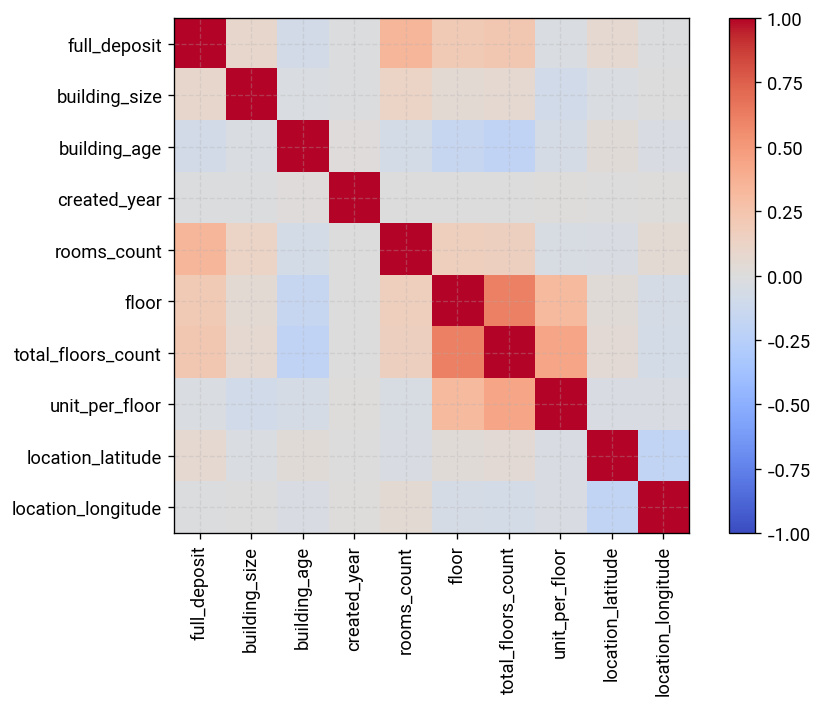

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = [
    "building_size",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "location_latitude",
    "location_longitude",
]

data = rent_df[features + ["full_deposit"]].dropna()

X = data[features]
y = data["full_deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Rows:", len(data))
print("R²:", r2_score(y_test, y_pred))

Rows: 79642
R²: 0.2988958133309698


In [30]:
import statsmodels.api as sm

X = data[features].astype(float)
y = data["full_deposit"].astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           full_deposit   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     4613.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:31:40   Log-Likelihood:            -1.7069e+06
No. Observations:               79642   AIC:                         3.414e+06
Df Residuals:                   79634   BIC:                         3.414e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -4.269e+08   4.74

In [31]:
import statsmodels.api as sm

remaining = features.copy()
selected = []

while remaining:
    scores = []

    for feature in remaining:
        cols = selected + [feature]
        X = sm.add_constant(data[cols].astype(float))
        y = data["full_deposit"].astype(float)

        model = sm.OLS(y, X).fit()
        scores.append((model.aic, feature))

    scores.sort()
    best_aic, best_feature = scores[0]

    selected.append(best_feature)
    remaining.remove(best_feature)

    print(f"{best_feature:25} AIC = {best_aic:.2f}")

print("\nSelected order:")
print(selected)

rooms_count               AIC = 3417755.59
total_floors_count        AIC = 3415592.93
building_size             AIC = 3414886.47
unit_per_floor            AIC = 3414322.90
location_latitude         AIC = 3413996.42
floor                     AIC = 3413872.59
location_longitude        AIC = 3413802.78

Selected order:
['rooms_count', 'total_floors_count', 'building_size', 'unit_per_floor', 'location_latitude', 'floor', 'location_longitude']


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

X = data[features].astype(float)
X = sm.add_constant(X)

vif = pd.DataFrame(
    {
        "Feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }
)
print(vif)

              Feature         VIF
0               const  740.828084
1       building_size    1.255425
2         rooms_count    1.292194
3               floor    1.596259
4  total_floors_count    1.776756
5      unit_per_floor    1.268664
6   location_latitude    1.030950
7  location_longitude    1.026875


In [33]:
# features = [
#     "building_size",
#     "rooms_count",
#     "floor",
#     "total_floors_count",
#     "unit_per_floor",
#     "location_latitude",
#     "location_longitude",
#     "city_slug",
#     "cat2_slug",
#     "cat3_slug",
#     "has_parking",
#     "has_elevator",
#     "has_warehouse",
#     "has_balcony",
#     "is_rebuilt",
# ]
features = [
    # "full_deposit",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]

In [34]:
data = rent_df[features + ["full_deposit"]].dropna().copy()

In [35]:
X = pd.get_dummies(
    data[features],
    columns=["city_slug", "created_month", "cat2_slug", "cat3_slug"],
    drop_first=True,
    dtype=int,
)

y = data["full_deposit"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Rows: {len(data)}")
print(f"Number of Features: {p}")
print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

Rows: 61476
Number of Features: 465
MAE: 241,582,064
RMSE: 349,761,370
R²: 0.6166
Adjusted R²: 0.6016


In [38]:
rent_df.info()

<class 'pandas.DataFrame'>
Index: 332526 entries, 2 to 999999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   full_deposit        332526 non-null  float32 
 1   has_balcony         181792 non-null  boolean 
 2   is_rebuilt          205441 non-null  boolean 
 3   has_elevator        220290 non-null  boolean 
 4   location_longitude  222651 non-null  float32 
 5   location_latitude   222651 non-null  float32 
 6   has_parking         282654 non-null  boolean 
 7   has_warehouse       282654 non-null  boolean 
 8   cat3_slug           332525 non-null  category
 9   building_age        332239 non-null  Int16   
 10  created_month       332526 non-null  category
 11  created_year        332526 non-null  Int16   
 12  rooms_count         332286 non-null  Int8    
 13  floor               220290 non-null  Int8    
 14  building_size       332525 non-null  float32 
 15  cat2_slug           332526 non-nu

In [45]:
rent_df = rent_df.dropna(subset=["city_slug", "cat3_slug"])

In [ ]:
# Numeric
numeric_cols = [
    "building_size",
    "rooms_count",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "location_latitude",
    "location_longitude",
    "building_age",
]
for col in numeric_cols:
    rent_df[col] = rent_df[col].fillna(rent_df[col].median())

# Boolean
bool_cols = [
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "is_rebuilt",
]
for col in bool_cols:
    rent_df[col] = rent_df[col].fillna(False)

In [48]:
print(rent_df.isna().sum())

full_deposit          0
has_balcony           0
is_rebuilt            0
has_elevator          0
location_longitude    0
location_latitude     0
has_parking           0
has_warehouse         0
cat3_slug             0
building_age          0
created_month         0
created_year          0
rooms_count           0
floor                 0
building_size         0
cat2_slug             0
city_slug             0
total_floors_count    0
unit_per_floor        0
dtype: int64


In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

features = [
    # "building_size",
    # "rooms_count",
    # "floor",
    # "total_floors_count",
    # "unit_per_floor",
    # "location_latitude",
    # "location_longitude",
    # "city_slug",
    # "cat2_slug",
    # "cat3_slug",
    # "has_parking",
    # "has_elevator",
    # "has_warehouse",
    # "has_balcony",
    # "is_rebuilt",
    "has_balcony",
    "is_rebuilt",
    "has_elevator",
    "location_longitude",
    "location_latitude",
    "has_parking",
    "has_warehouse",
    "cat3_slug",
    "building_age",
    "created_month",
    "created_year",
    "rooms_count",
    "floor",
    "building_size",
    "cat2_slug",
    "city_slug",
    "total_floors_count",
    "unit_per_floor",
]

data = rent_df[features + ["full_deposit"]].copy()

X = pd.get_dummies(
    data[features],
    columns=[
        "city_slug",
        "created_month",
        "cat2_slug",
        "cat3_slug",
    ],
    drop_first=True,
    dtype=int,
)

y = data["full_deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Rows: {len(data)}")
print(f"Number of Features: {p}")
print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

Rows: 332524
Number of Features: 465
MAE: 296,591,422
RMSE: 443,001,493
R²: 0.4550
Adjusted R²: 0.4511


---

#### Ridge Regression

In [50]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {"alpha": [0.01, 0.1, 1, 10, 100, 1000]}

grid = GridSearchCV(estimator=ridge, param_grid=params, cv=5, scoring="r2", n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

MemoryError: Unable to allocate 4.47 MiB for an array with shape (11, 53204) and data type int64

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Best alpha:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

Best alpha: {'alpha': 10}
Best CV R²: 0.3478846865212844
MAE: 516,813,578
RMSE: 800,235,871
R²: 0.3348
Adjusted R²: 0.2805


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso(max_iter=10000)

params = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(estimator=lasso, param_grid=params, cv=5, scoring="r2", n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Best alpha:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

#### Tree Models

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

MAE: 344,627,801
RMSE: 641,790,101
R²: 0.5721
Adjusted R²: 0.5372


In [ ]:
import pandas as pd

importance = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": model.feature_importances_}
)

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(20))

                        Feature  Importance
0                 building_size    0.358695
388            city_slug_tehran    0.178009
5             location_latitude    0.099963
6            location_longitude    0.077113
1                   rooms_count    0.040984
2                         floor    0.028568
8                  has_elevator    0.018909
423         cat3_slug_shop-rent    0.017404
3            total_floors_count    0.010418
413  cat2_slug_residential-rent    0.008627
186             city_slug_karaj    0.007852
362            city_slug_shiraz    0.007689
4                unit_per_floor    0.006914
9                 has_warehouse    0.006357
251           city_slug_mashhad    0.006241
10                  has_balcony    0.006165
7                   has_parking    0.005678
169           city_slug_isfahan    0.005223
314             city_slug_rasht    0.004879
11                   is_rebuilt    0.004367


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

#### Boosting

In [61]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

MAE: 199,602,128
RMSE: 334,136,426
R²: 0.6899
Adjusted R²: 0.6878


In [71]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

model = XGBRegressor(param_grid=param_grid, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

n = len(y_test)
p = X_test.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

c:\Users\fam-01\.conda\envs\quera\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:53:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "param_grid" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE: 192,008,208
RMSE: 326,318,466
R²: 0.7043
Adjusted R²: 0.7022


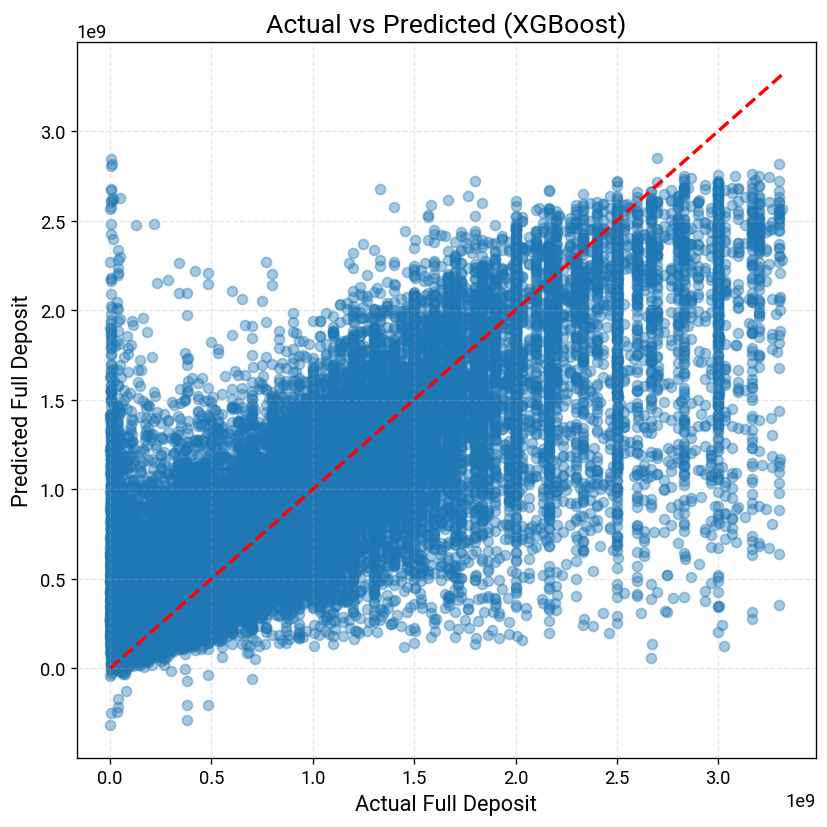

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)

plt.xlabel("Actual Full Deposit")
plt.ylabel("Predicted Full Deposit")
plt.title("Actual vs Predicted (XGBoost)")

plt.tight_layout()
plt.show()

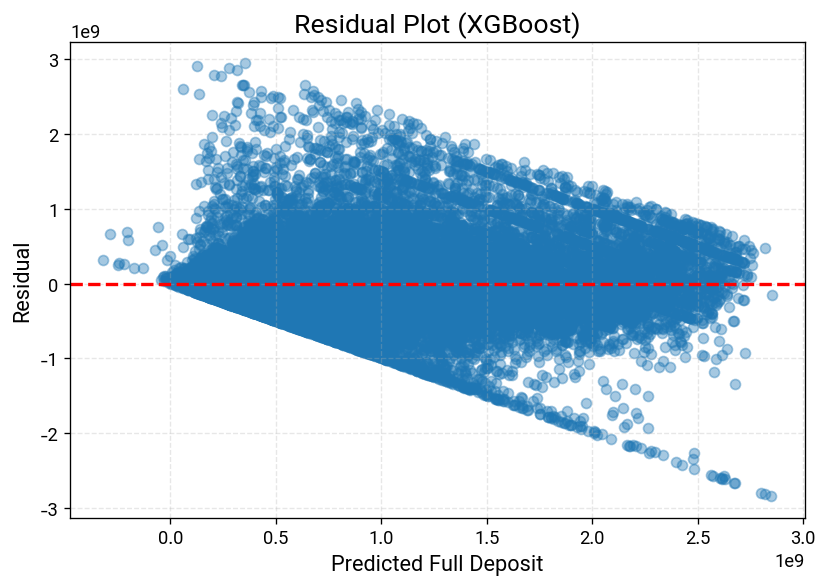

In [53]:
residuals = y_test - y_pred

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(y=0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted Full Deposit")
plt.ylabel("Residual")
plt.title("Residual Plot (XGBoost)")

plt.tight_layout()
plt.show()

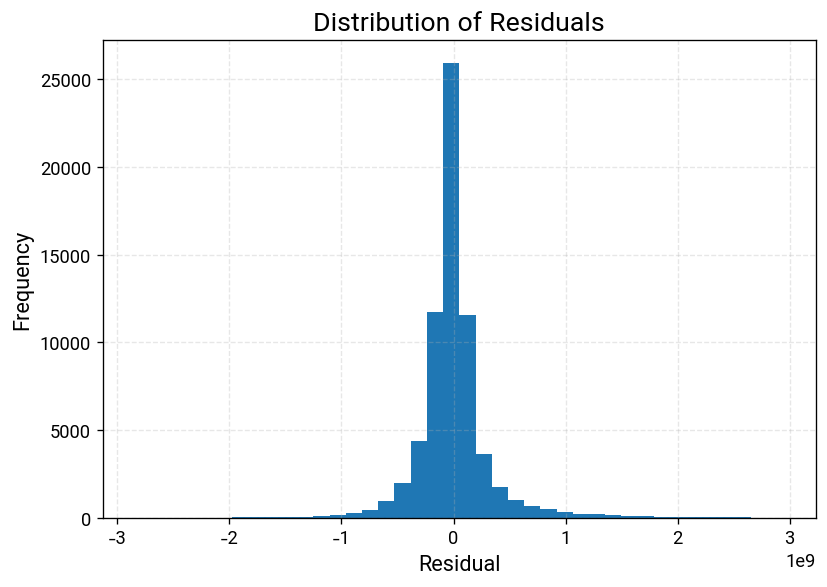

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=40)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Lasso Feature Selection

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import pandas as pd

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(cv=5, random_state=42, max_iter=10000)),
    ]
)

pipeline.fit(X_train, y_train)

lasso = pipeline.named_steps["lasso"]

coef = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lasso.coef_})

coef = coef.sort_values("Coefficient", key=abs, ascending=False)

print("Best alpha:", lasso.alpha_)
print("Selected Features:", (coef["Coefficient"] != 0).sum())
print("Removed Features :", (coef["Coefficient"] == 0).sum())

coef.head(30)

Best alpha: 253879.47451639886
Selected Features: 412
Removed Features : 53


,Feature,Coefficient
409,city_slug_tehran,2.806918e+08
9,rooms_count,2.123472e+08
460,cat3_slug_shop-rent,1.375682e+08
447,cat2_slug_residential-rent,-1.115844e+08
2,has_elevator,9.385314e+07
5,has_parking,8.100467e+07
380,city_slug_shiraz,5.642474e+07
226,city_slug_kish,5.568569e+07
194,city_slug_karaj,5.081216e+07
453,cat3_slug_industry-agriculture-business-rent,4.728216e+07


In [56]:
selected_features = coef.loc[coef["Coefficient"] != 0, "Feature"].tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

model = LinearRegression()
model.fit(X_train_selected, y_train)

y_pred = model.predict(X_test_selected)

n = len(y_test)
p = X_test_selected.shape[1]

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Features:", p)
print("MAE:", f"{mae:,.0f}")
print("RMSE:", f"{rmse:,.0f}")
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adj_r2, 4))

Features: 412
MAE: 296,616,980
RMSE: 442,990,613
R²: 0.455
Adjusted R²: 0.4516


#### Dimension Reduction

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA()
pca.fit(X_train_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Number of components for 95%
n_components = np.argmax(cum_var >= 0.95) + 1

print("Original Features:", X_train.shape[1])
print("Components for 95% variance:", n_components)

Original Features: 465
Components for 95% variance: 410


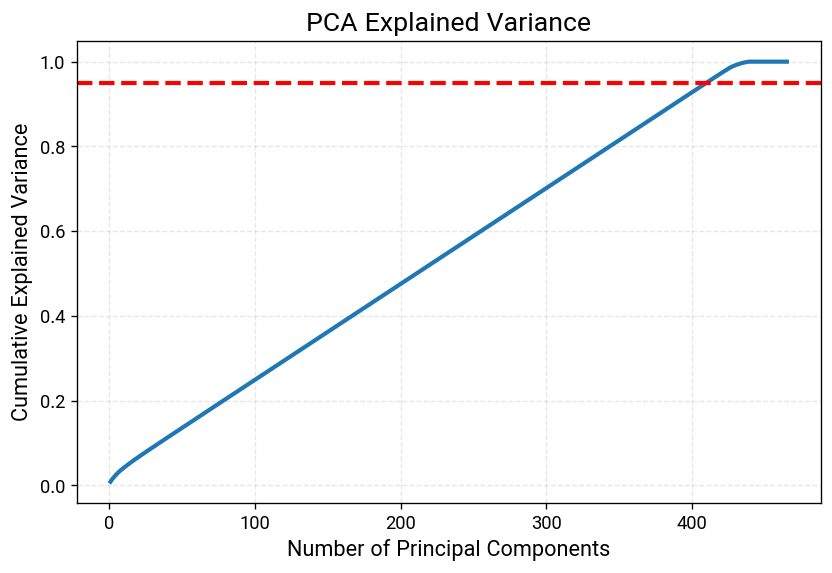

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cum_var) + 1), cum_var)

plt.axhline(y=0.95, color="red", linestyle="--")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [59]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pcr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=336)),
        ("lr", LinearRegression()),
    ]
)

pcr.fit(X_train, y_train)

y_pred = pcr.predict(X_test)

n = len(y_test)
p = 336

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

MAE: 338,193,383
RMSE: 498,429,496
R²: 0.3101
Adjusted R²: 0.3066


#### SHAP

In [72]:
import shap
# model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

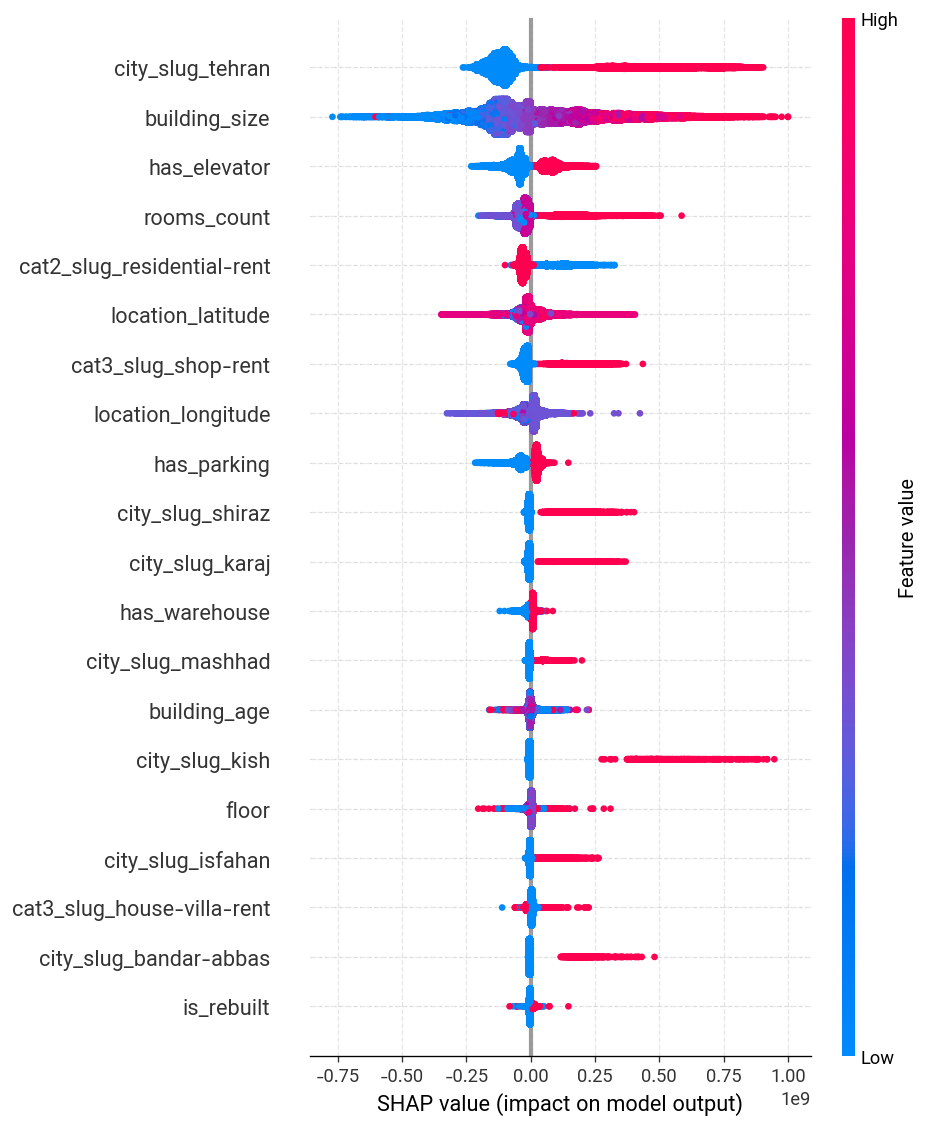

In [73]:
shap.summary_plot(shap_values, X_test)

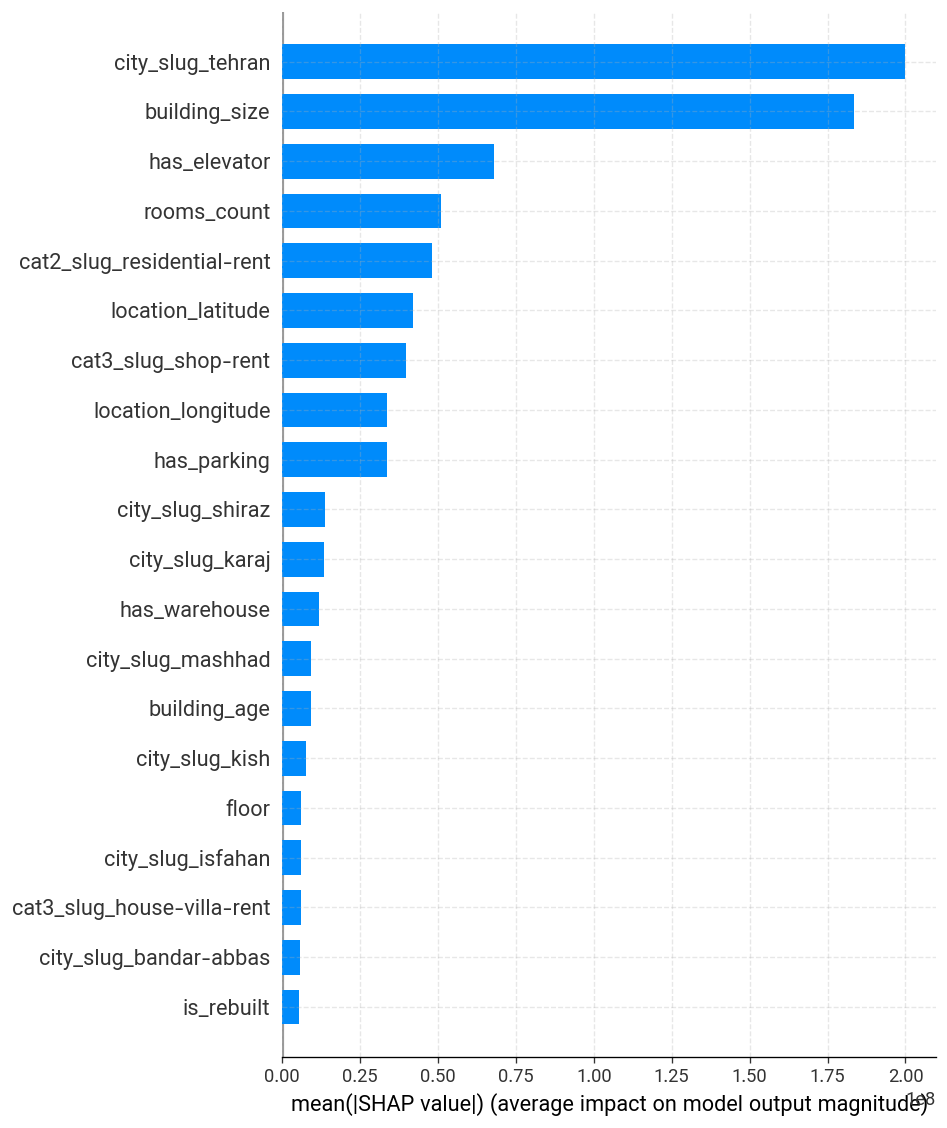

In [74]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

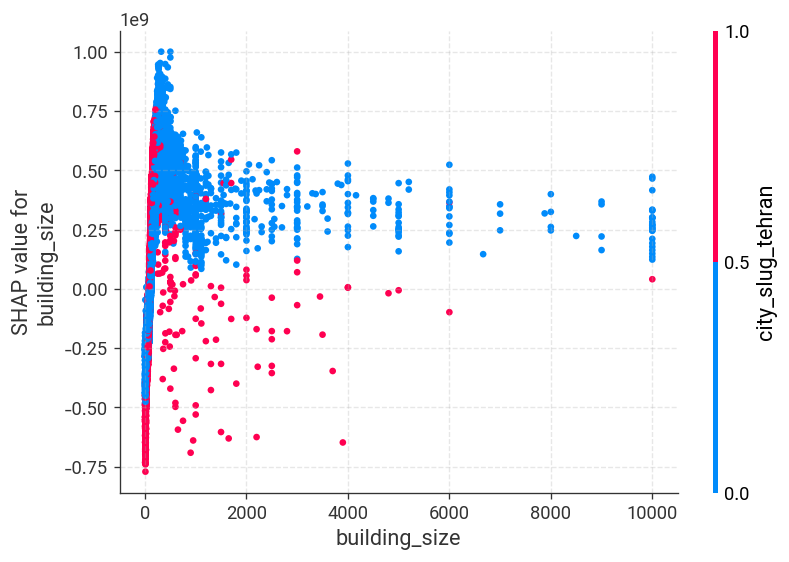

In [75]:
shap.dependence_plot("building_size", shap_values, X_test)

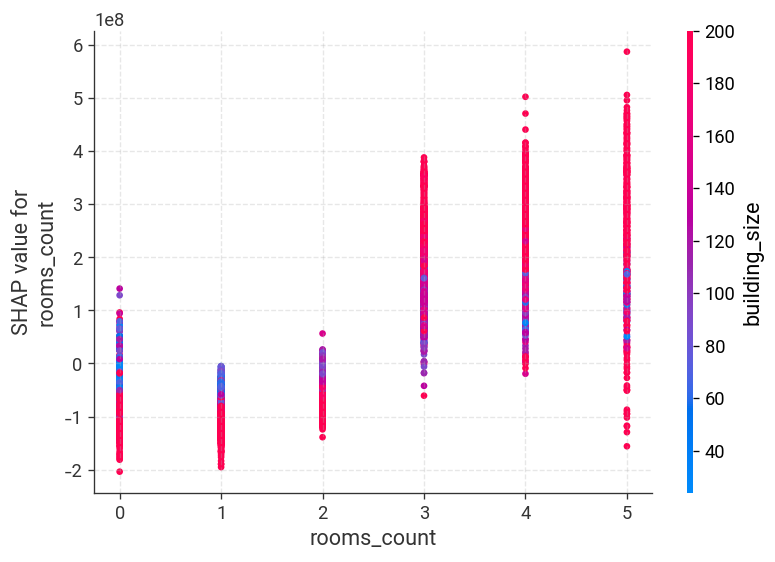

In [76]:
shap.dependence_plot("rooms_count", shap_values, X_test)

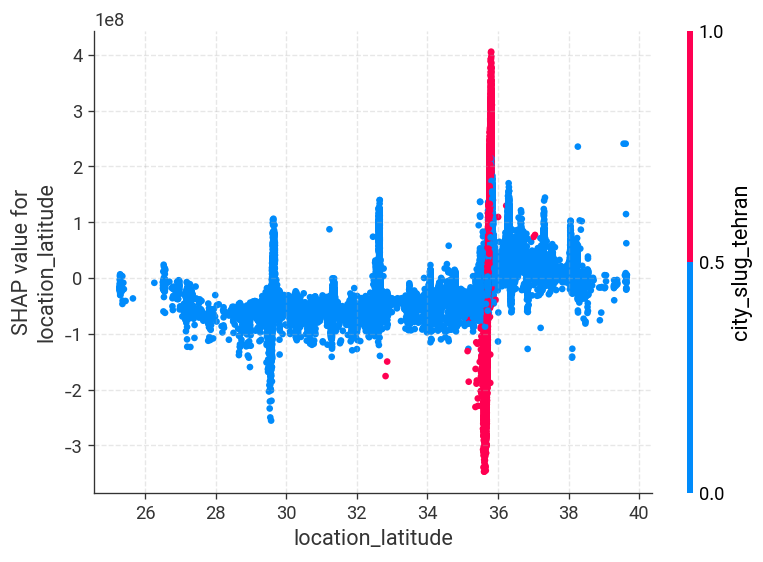

In [77]:
shap.dependence_plot("location_latitude", shap_values, X_test)

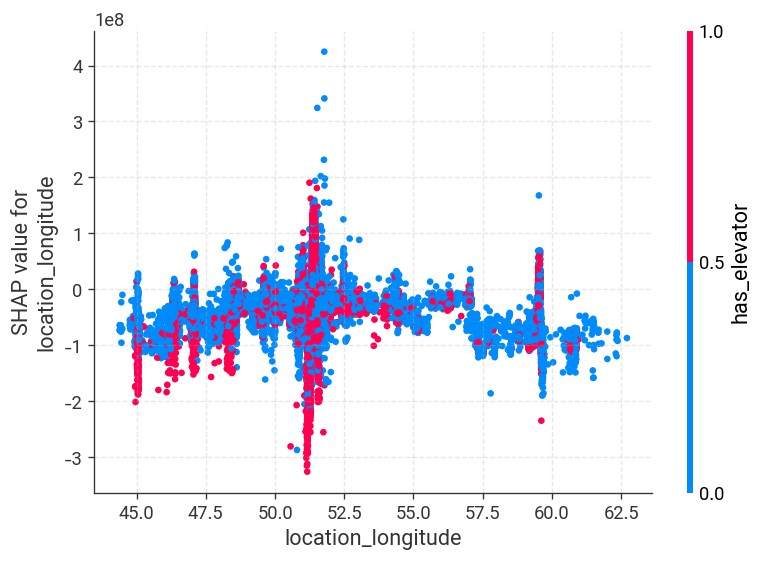

In [78]:
shap.dependence_plot("location_longitude", shap_values, X_test)

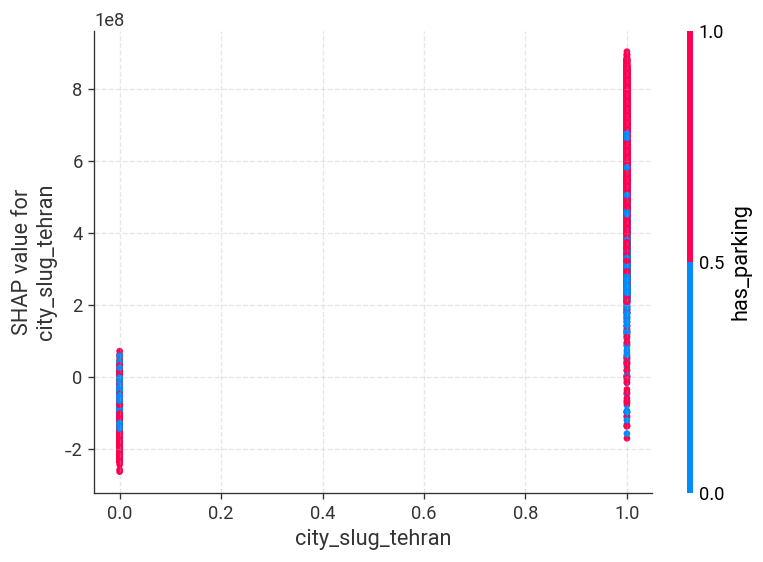

In [79]:
shap.dependence_plot("city_slug_tehran", shap_values, X_test)

In [80]:
shap.initjs()

shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])